In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

In [3]:
len(x_train)

60000

In [4]:
len(x_test)

10000

In [5]:
x_train[0].shape

(28, 28)

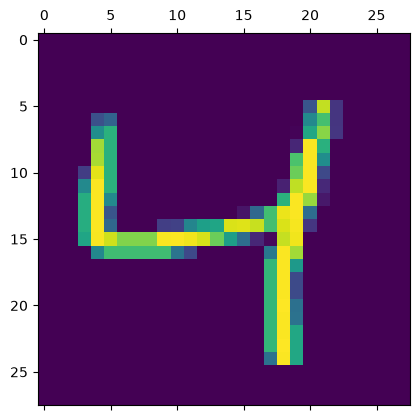

In [6]:
plt.matshow(x_train[2])

In [7]:
y_train[2]

np.uint8(4)

In [8]:
y_train[:9]

array([5, 0, 4, 1, 9, 2, 1, 3, 1], dtype=uint8)

In [9]:
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train_flattened=x_train.reshape(len(x_train),28*28)
x_test_flattened=x_test.reshape(len(x_test),28*28)

x_train_flattened.shape

(60000, 784)

In [10]:
model = keras.Sequential([
    keras.layers.Dense(10, input_shape=(784,), activation='sigmoid')
])

# 5. Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Fit the model
model.fit(x_train_flattened, y_train, epochs=5)

c:\Users\taimo\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8762 - loss: 0.4699
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9149 - loss: 0.3044
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9213 - loss: 0.2831
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9235 - loss: 0.2735
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9257 - loss: 0.2667


In [11]:
model.evaluate(x_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9253 - loss: 0.2688


[0.26879575848579407, 0.9253000020980835]

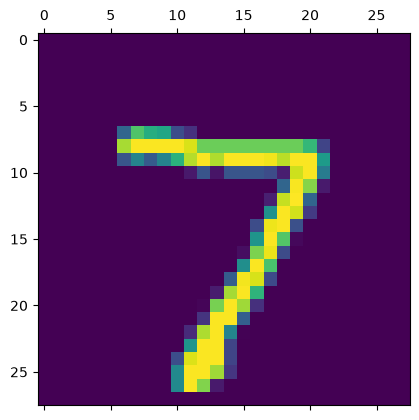

In [12]:
plt.matshow(x_test[0])

In [13]:
y_predicted=model.predict(x_test_flattened)
y_predicted[0]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 833us/step


array([2.7641546e-02, 2.5398163e-07, 6.7097299e-02, 9.6376371e-01,
       3.3261180e-03, 1.0938332e-01, 1.2838901e-06, 9.9988312e-01,
       8.4766999e-02, 7.0348984e-01], dtype=float32)

In [14]:
np.argmax(y_predicted[0])

np.int64(7)

In [15]:
y_predicted_labels=[np.argmax(i) for i in y_predicted]
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [16]:
y_test[:5]

array([7, 2, 1, 0, 4], dtype=uint8)

In [17]:
cm=tf.math.confusion_matrix(labels=y_test,predictions=y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 964,    0,    1,    2,    0,    5,    4,    2,    1,    1],
       [   0, 1110,    3,    2,    0,    1,    4,    2,   13,    0],
       [   7,    9,  915,   24,   10,    3,   11,   10,   39,    4],
       [   3,    0,   15,  945,    0,   13,    2,   10,   13,    9],
       [   2,    1,    4,    2,  922,    0,    8,    4,    9,   30],
       [  10,    1,    4,   50,   11,  760,   13,    7,   29,    7],
       [  13,    3,    8,    1,    8,   13,  909,    2,    1,    0],
       [   1,    5,   21,    8,    9,    0,    0,  952,    2,   30],
       [   7,    5,    7,   35,    9,   23,    9,   12,  860,    7],
       [  11,    6,    1,   14,   28,    5,    0,   24,    4,  916]],
      dtype=int32)>

Text(95.83333333333333, 0.5, 'Truth')

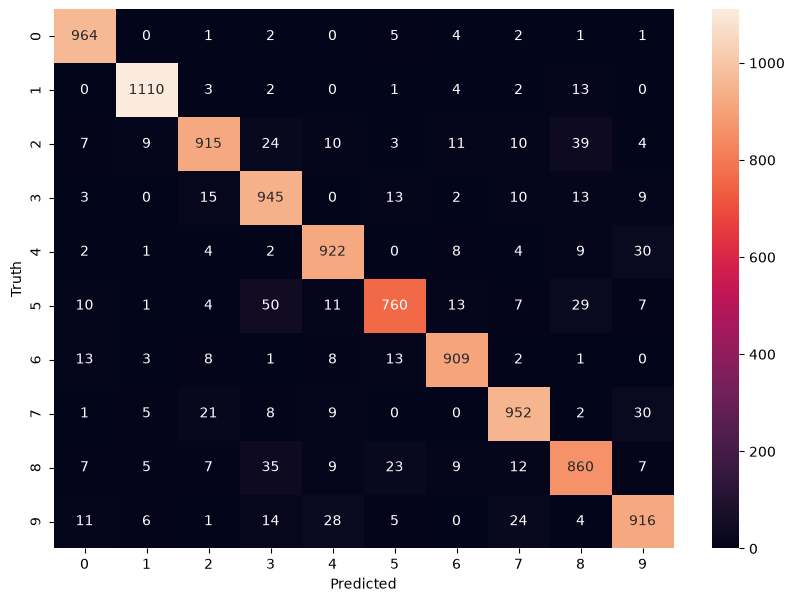

In [18]:
import seaborn as sn
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True,fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Truth")

In [ ]:
model = keras.Sequential([
    keras.layers.Dense(100, input_shape=(784,), activation='relu'),
    keras.layers.Dense(10, activation='sigmoid')

])
tb_callbacks=tf.keras.callbacks.TensorBoard(log_dir="logs/",histogram_freq=1)
# 5. Compile
model.compile(
    optimizer='SGD',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Fit the model
model.fit(x_train_flattened, y_train, epochs=5,callbacks=tb_callbacks)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8213 - loss: 0.7027
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9039 - loss: 0.3438
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9175 - loss: 0.2923
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9265 - loss: 0.2612
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9329 - loss: 0.2379


In [22]:
model.evaluate(x_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9357 - loss: 0.2226


[0.2225790023803711, 0.935699999332428]